# Set-up

In [154]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme, extract_loci

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

In [155]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [156]:
os.chdir('/cellar/users/aklie/projects/igvf/ChromBetaNet')

In [157]:
path_out = "scratch/2025_04_29"

In [158]:
dtype = torch.float64

seq_len = 2114
target_len = 1000
mut_window = 500
plot_window = 200

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - mut_window // 2
seq_end = seq_center + mut_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - mut_window // 2
target_end = target_center + mut_window // 2

# Plot starts
plot_seq_center = 1050
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 807, seq_end: 1307
target_start: 250, target_end: 750
plot_seq_start: 957, plot_seq_end: 1157
plot_target_start: 400, plot_target_end: 600


# Load genome

In [159]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [160]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [161]:
path_peaks = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/3-cyt_rna_celltype/snapatac2/SC.beta.narrowPeak"
path_schema = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/3-cyt_rna_celltype/snapatac2/SC.beta.narrowPeak.schema"
schema = pd.read_csv(path_schema, header=None, sep='\t')[0].tolist()  # convert schema to a list
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=schema)  # corrected to use schema

In [162]:
# Remove duplicate chrom start and end taking the highest q_value
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
14,chr1,633836,634204,.,1000,.,42.279079,73397.093750,73389.039062,195
127041,chr17,22521245,22521563,.,1000,.,40.785767,22357.759766,22350.675781,153
134584,chr17,64918885,64920034,.,1000,.,26.950092,18425.957031,18419.052734,649
3861,chr1,16644224,16645279,.,1000,.,20.648632,17835.375000,17828.492188,508
3844,chr1,16612670,16614046,.,1000,.,20.504276,16820.847656,16814.080078,934
...,...,...,...,...,...,...,...,...,...,...
47958,chr11,256029,256260,.,13,.,1.347393,2.615740,1.301980,91
282936,chr7,78218239,78218457,.,13,.,1.418290,2.615570,1.301823,99
208778,chr3,37059792,37060045,.,13,.,1.418290,2.615570,1.301823,184
64034,chr11,126548318,126548676,.,13,.,1.411043,2.615290,1.301552,119


# Load motifs

In [163]:
motifs = read_meme("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")
motif_names = np.array(list(motifs.keys()))

In [164]:
tmp = pd.read_csv("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/tfs_initial.txt", header=None, sep='\t', names=["motif_id", "annotated_tf"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]

# Load model

In [165]:
path_model = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/SC.beta/fold_0/chrombpnet/0.8/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [166]:
count_wrapper = CountWrapper(model).cuda().eval()

# Original sequence

In [167]:
# 
chrom = "chr4"
start = 84432784
end = 84434897

In [168]:
original_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTGGTGAAAACAATCTGAGGAGAACAAGGGCTCTGTTTTTTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()
len(original_seq)

2114

In [169]:
# Get the sequence corresponding to the region of interest from the genome fasta
seq = genome[chrom][start-1:end].seq.upper()
seq

'AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATGAGGTGAGGGCAAGATGGAGGTGGGGTGGAGGCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGAT

In [170]:
seq == original_seq

True

In [172]:
# Get predictions
original_seq_onehot = np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_profile, original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())
original_pred = original_counts * original_profile
print(f"original counts: {original_counts}")

original counts: 3127.501708984375


In [173]:
# Get attribution scores for the original sequence
X_attr = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr.shape

100%|██████████| 20/20 [00:00<00:00, 24.39it/s]


torch.Size([1, 4, 2114])

In [174]:
seqlets = recursive_seqlets(X_attr[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(original_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [175]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXB1_forkhead_2,963,979,0.485643,0.002770
1,FOSL2_MOUSE.H11MO.0.A,954,968,0.017670,0.013889
2,FOXA2_HUMAN.H11MO.0.A,807,818,-2.422872,0.034722


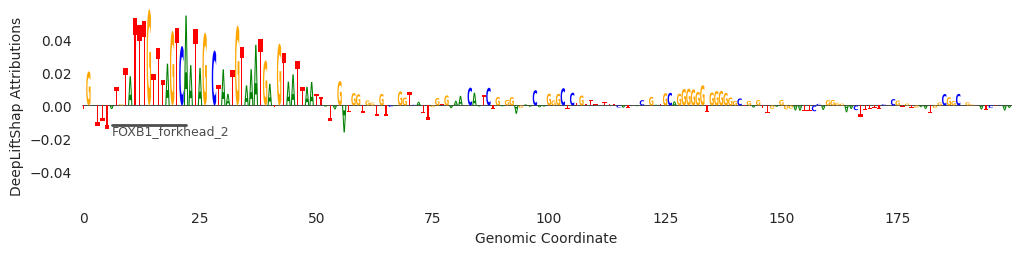

In [176]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

In [177]:
wild_type_enhancer_counts = np.log(original_counts)

# Mutated sequence

In [178]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [179]:
mutated_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTTGTGTAAACAATCTGAGGTAAACAAGGGCTCTGTTTACTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()

In [180]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(1032, 'G', 'T'),
 (1036, 'A', 'T'),
 (1050, 'A', 'T'),
 (1051, 'G', 'A'),
 (1068, 'T', 'A'),
 (1069, 'T', 'C')]

In [181]:
# add left flank and right flank to mutated sequence
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
mutated_pred = mutated_counts * mutated_profile
print(f"mutated counts: {mutated_counts}")

mutated counts: 9674.3447265625


In [182]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=4,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.41it/s]


torch.Size([1, 4, 2114])

In [183]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [184]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,1028,1047,0.615272,0.013699
1,HOXB3_MA0903.1,907,921,-0.018921,0.015152
2,FOXB1_forkhead_2,963,979,0.553899,0.016393


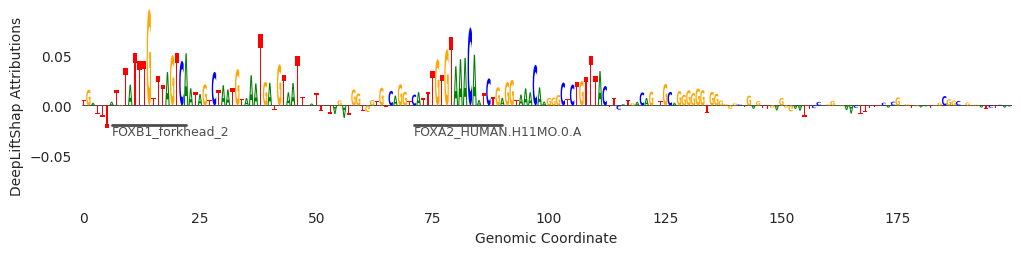

In [185]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

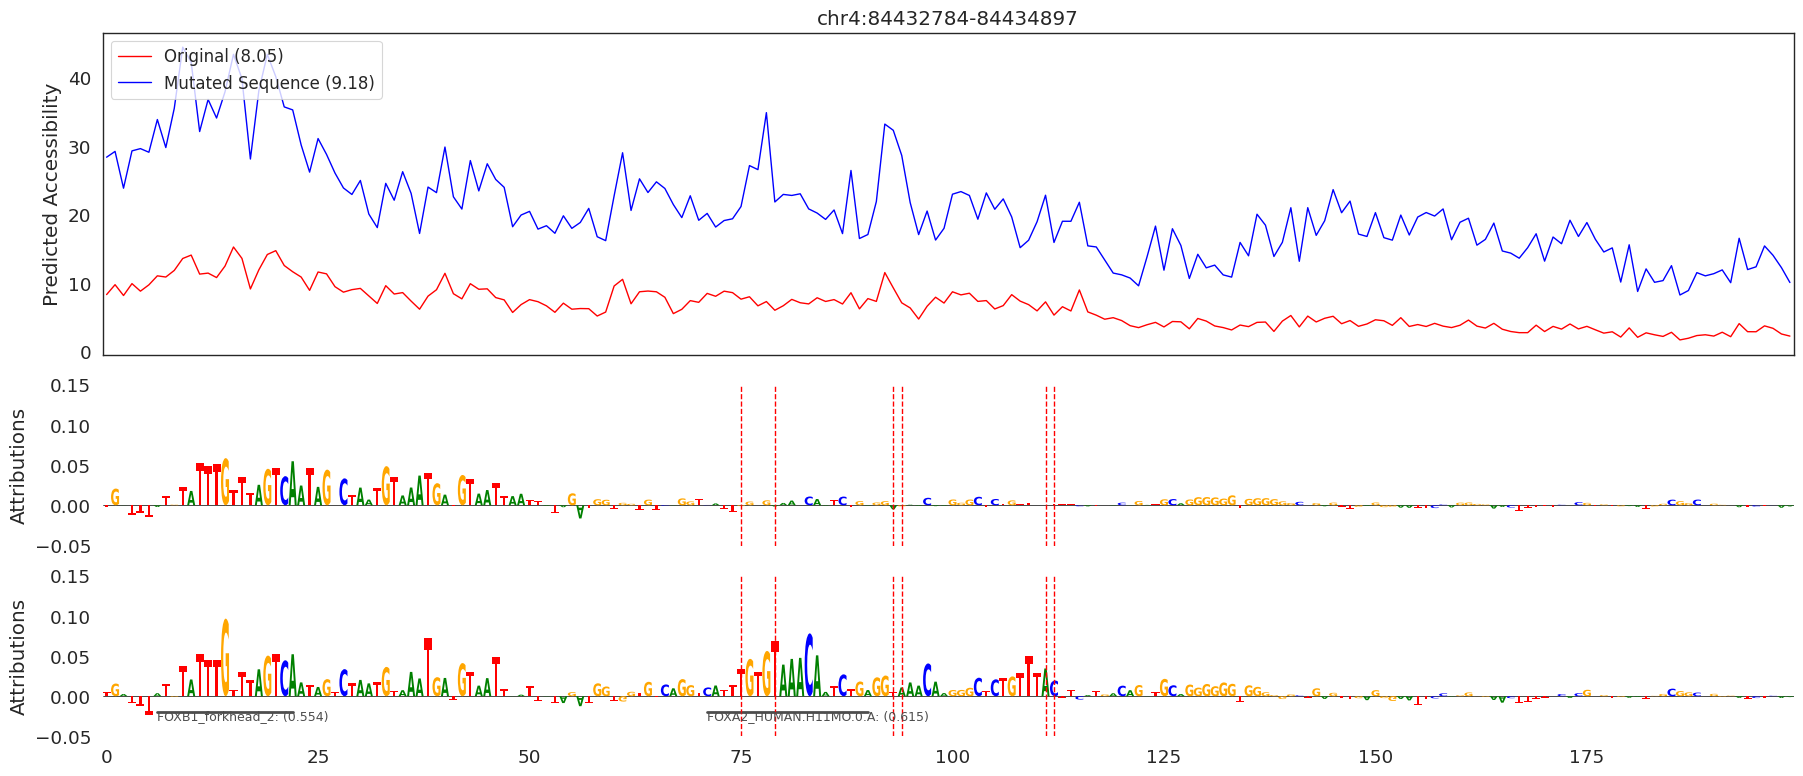

In [186]:
offset = 0

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_1_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [187]:
validated_mutated_enhancer_counts = np.log(mutated_counts)

# Get baseline level of predictions

In [188]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [189]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=["/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/3-cyt_rna_celltype/count_bws/SC.beta_unstranded.bw"],
    chroms=["chr4"]
)

In [190]:
y_0 = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

100%|██████████| 352/352 [00:11<00:00, 31.12it/s]


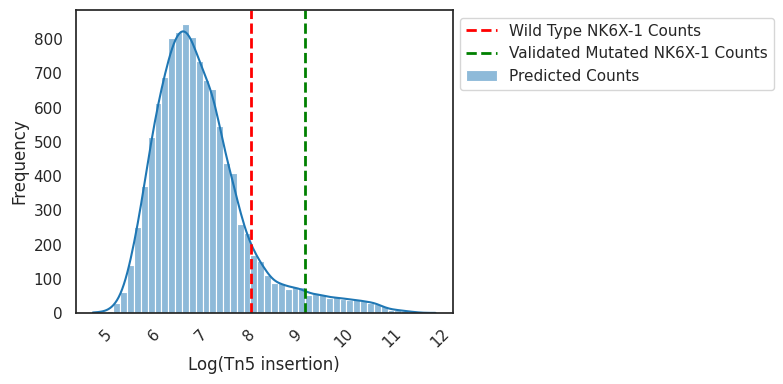

In [193]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        y_0,
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot NKX6-1 Enhancer Original as vertical line
    ax.axvline(x=wild_type_enhancer_counts, color='red', linestyle='--', linewidth=2, label='Wild Type NK6X-1 Counts')
    
    # Plot NKX6-1 Enhancer Mutated as vertical line
    ax.axvline(x=validated_mutated_enhancer_counts, color='green', linestyle='--', linewidth=2, label='Validated Mutated NK6X-1 Counts')

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# ISM

In [194]:
import sys
sys.path.append(path_out)
from utils import greedy_ism

In [195]:
ism_window = 500

## Maximize predictions

In [196]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [197]:
X_ = torch.tensor(original_seq_onehot)

In [198]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 8.048
Iteration 1/10 - y_hat: 8.541
Iteration 2/10 - y_hat: 8.866
Iteration 3/10 - y_hat: 9.351
Iteration 4/10 - y_hat: 9.717
Iteration 5/10 - y_hat: 10.105
Iteration 6/10 - y_hat: 10.493
Iteration 7/10 - y_hat: 10.732
Iteration 8/10 - y_hat: 10.980
Iteration 9/10 - y_hat: 11.285
Iteration 10/10 - y_hat: 11.558


In [199]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.14it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

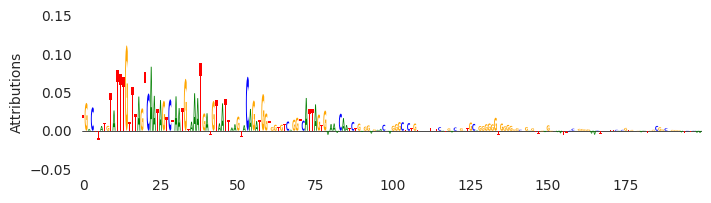

In [200]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [201]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(903, 'G', 'T'),
 (913, 'T', 'G'),
 (914, 'T', 'C'),
 (920, 'C', 'A'),
 (929, 'A', 'C'),
 (943, 'A', 'G'),
 (960, 'T', 'C'),
 (1007, 'T', 'G'),
 (1010, 'T', 'C'),
 (1032, 'G', 'A')]

In [202]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 104688.73093900736


((1000,), (1000,))

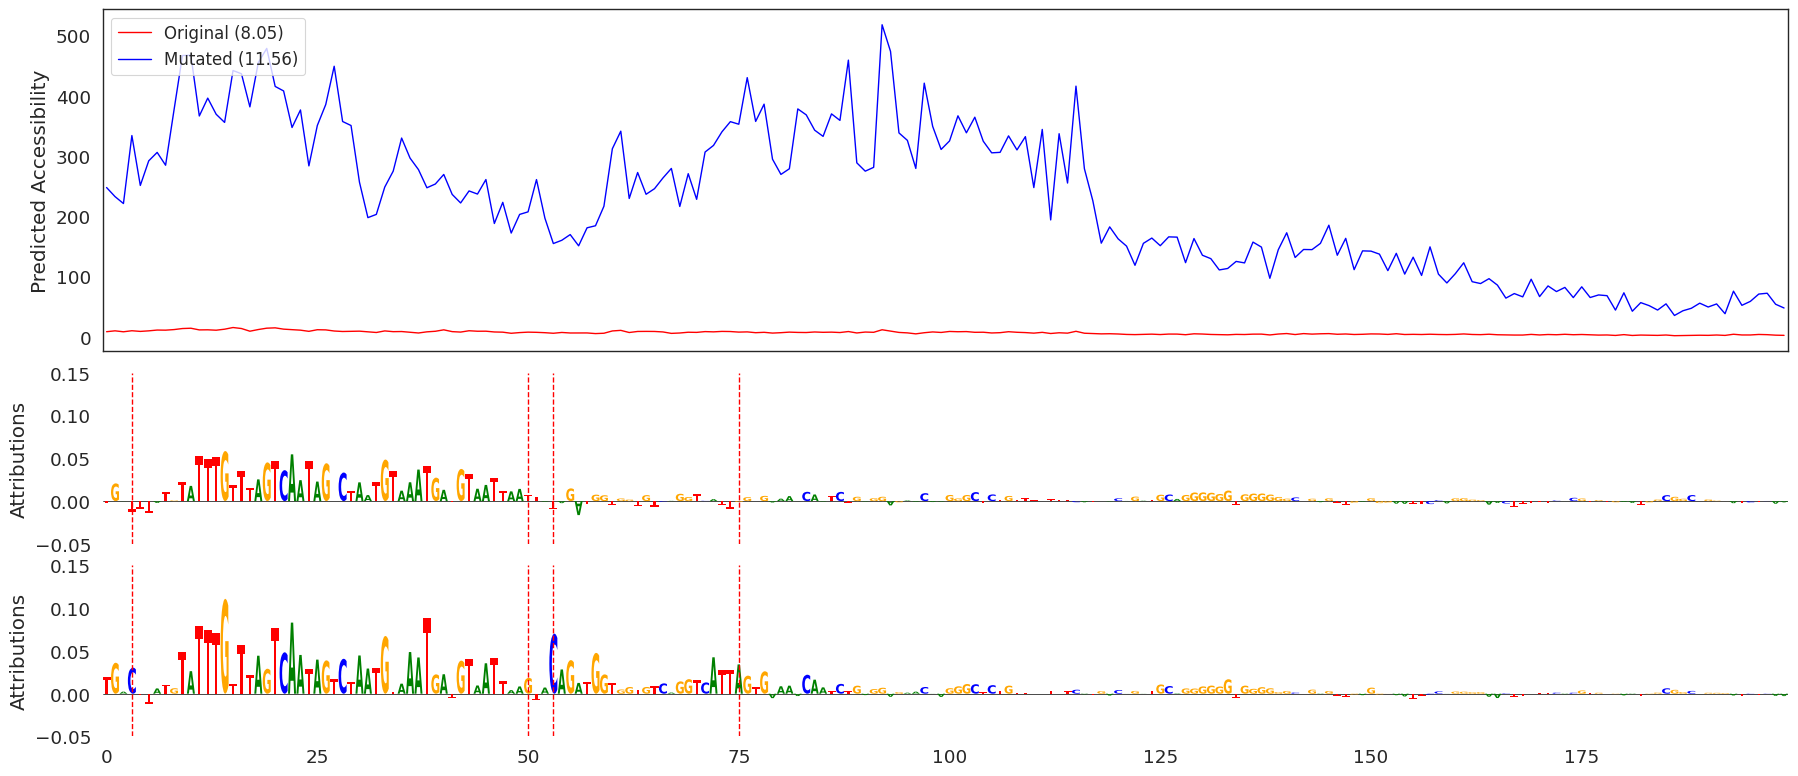

In [203]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [204]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [205]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,HNF1B_HUMAN.H11MO.0.A,918,934,0.842144,0.005038
1,HNF1B_HUMAN.H11MO.0.A,902,919,1.109978,0.019802
2,FOXB1_forkhead_2,963,977,0.598440,0.039900


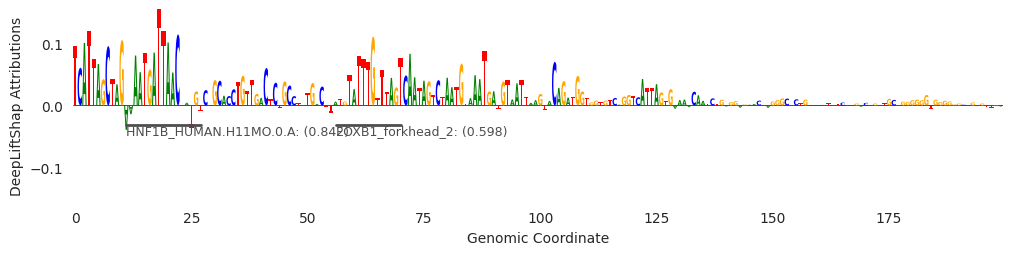

In [206]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

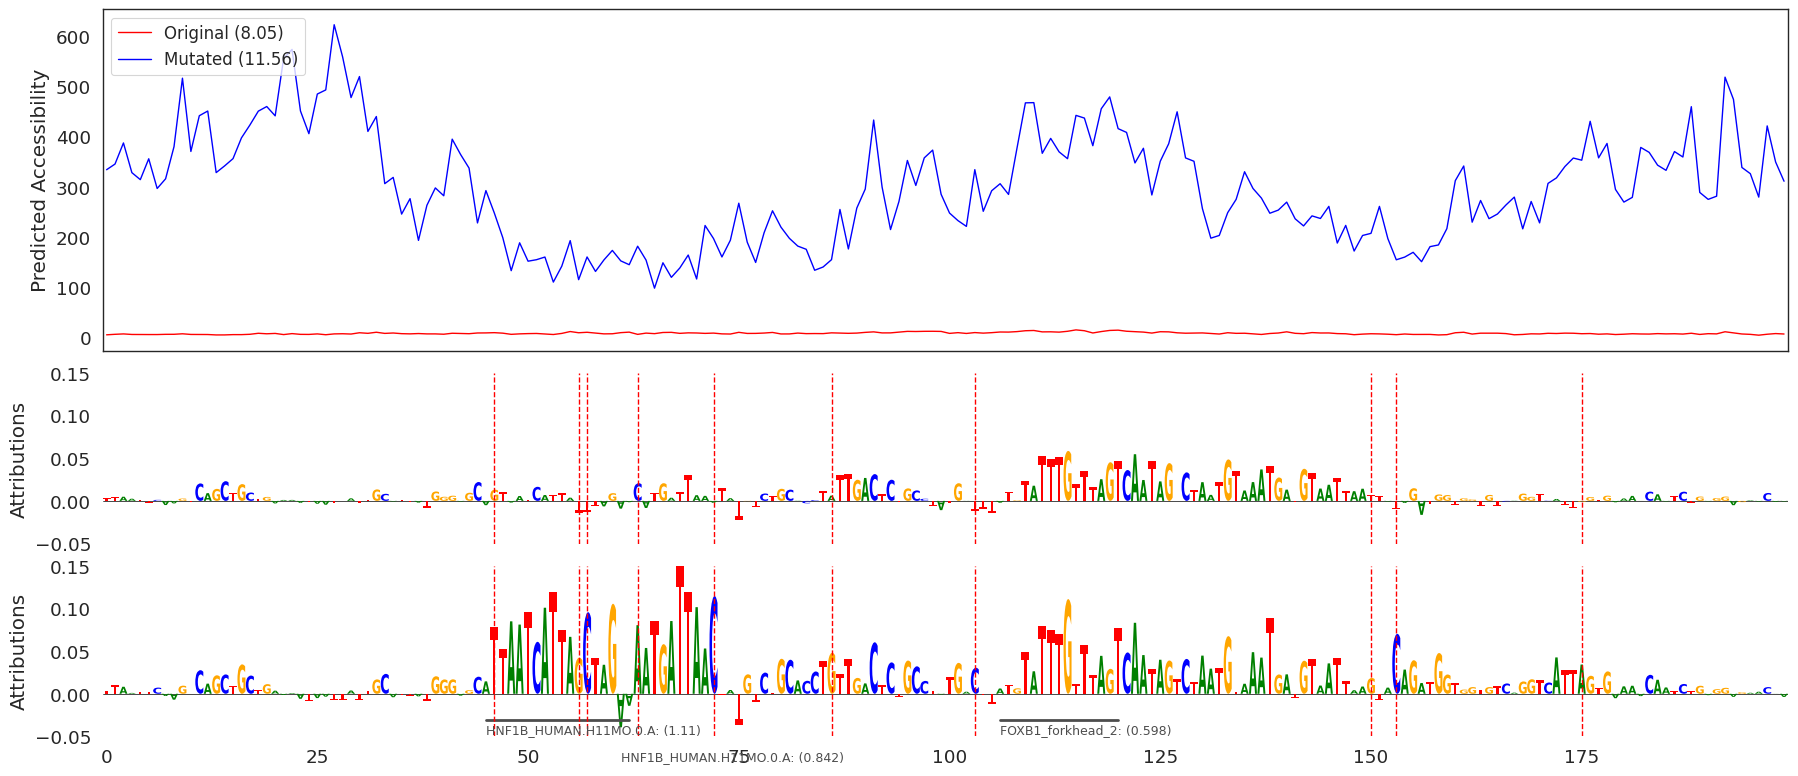

In [211]:
offset = -100

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [212]:
maximum_counts = np.log(mutated_counts)

## Try to match the validated one

In [213]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [214]:
X_ = torch.tensor(original_seq_onehot)

In [215]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=3,
    verbose=True,
)

Iteration 0/3 - y_hat: 8.048
Iteration 1/3 - y_hat: 8.541
Iteration 2/3 - y_hat: 8.866
Iteration 3/3 - y_hat: 9.351


In [216]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.36it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

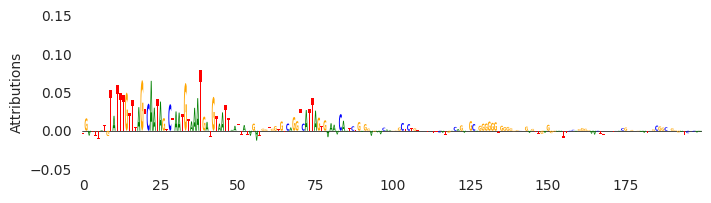

In [217]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [218]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(920, 'C', 'A'), (929, 'A', 'C'), (1032, 'G', 'A')]

In [219]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 11515.212839764796


((1000,), (1000,))

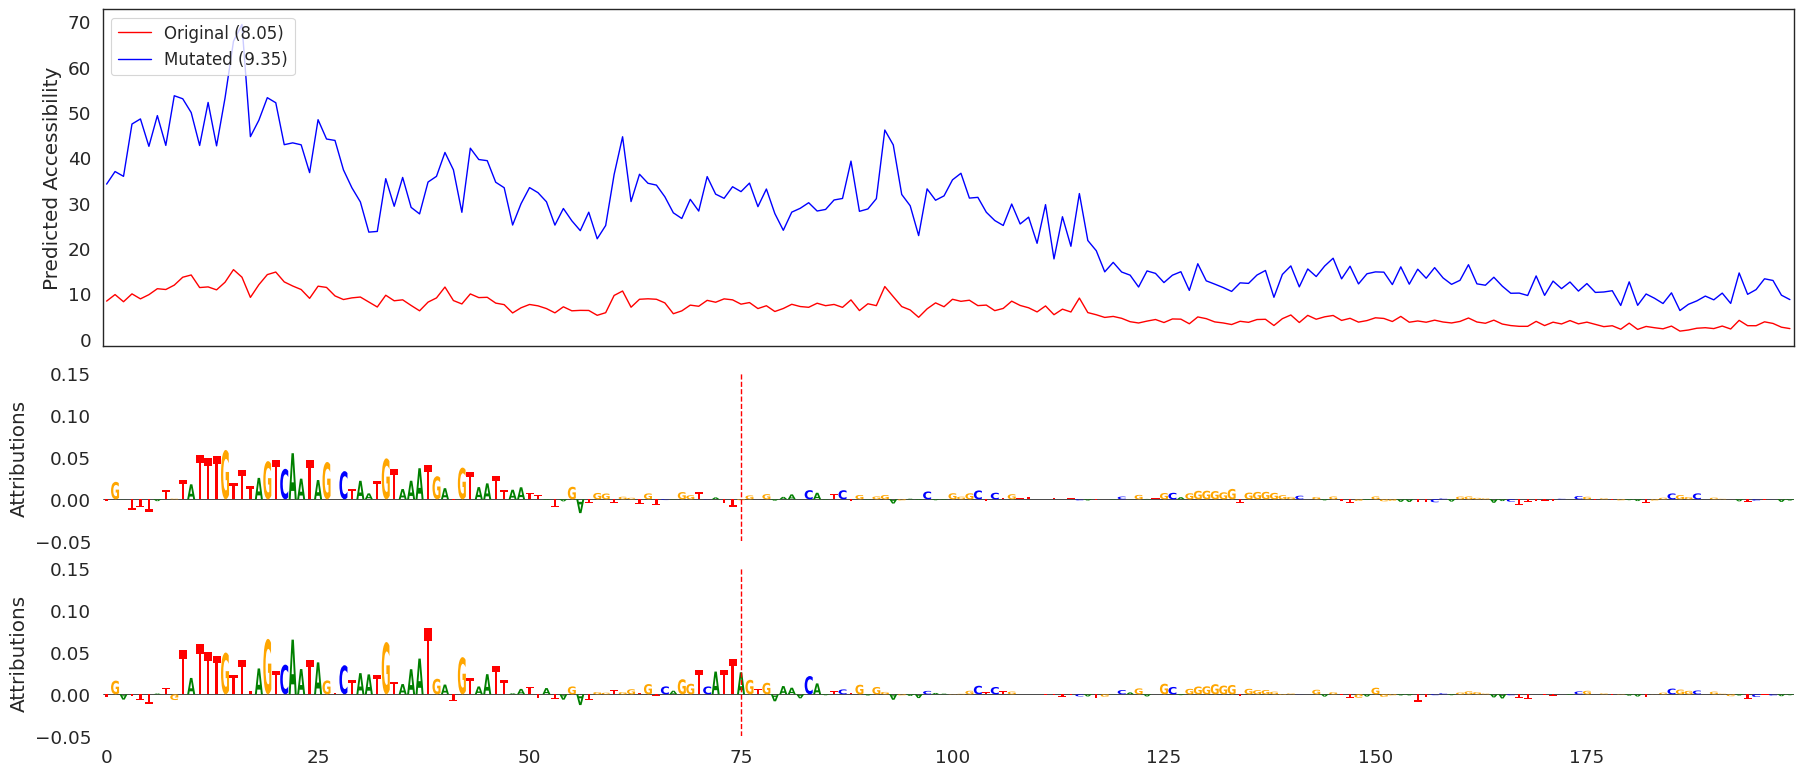

In [220]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [221]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [222]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,HNF1B_HUMAN.H11MO.0.A,918,935,0.788588,0.008197
1,FOXB1_forkhead_2,961,977,0.424457,0.032787
2,FOXB1_forkhead_2,973,987,0.447360,0.040984


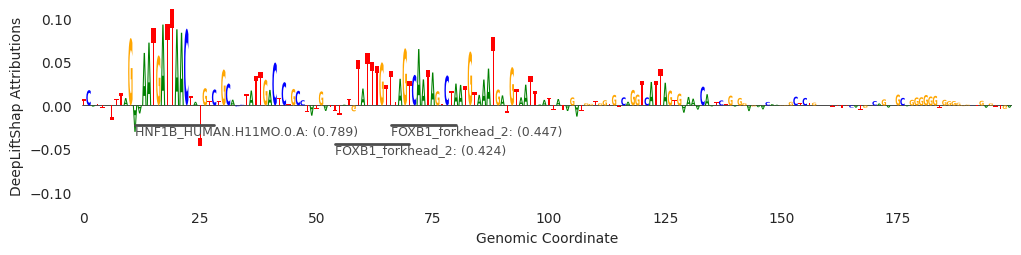

In [223]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

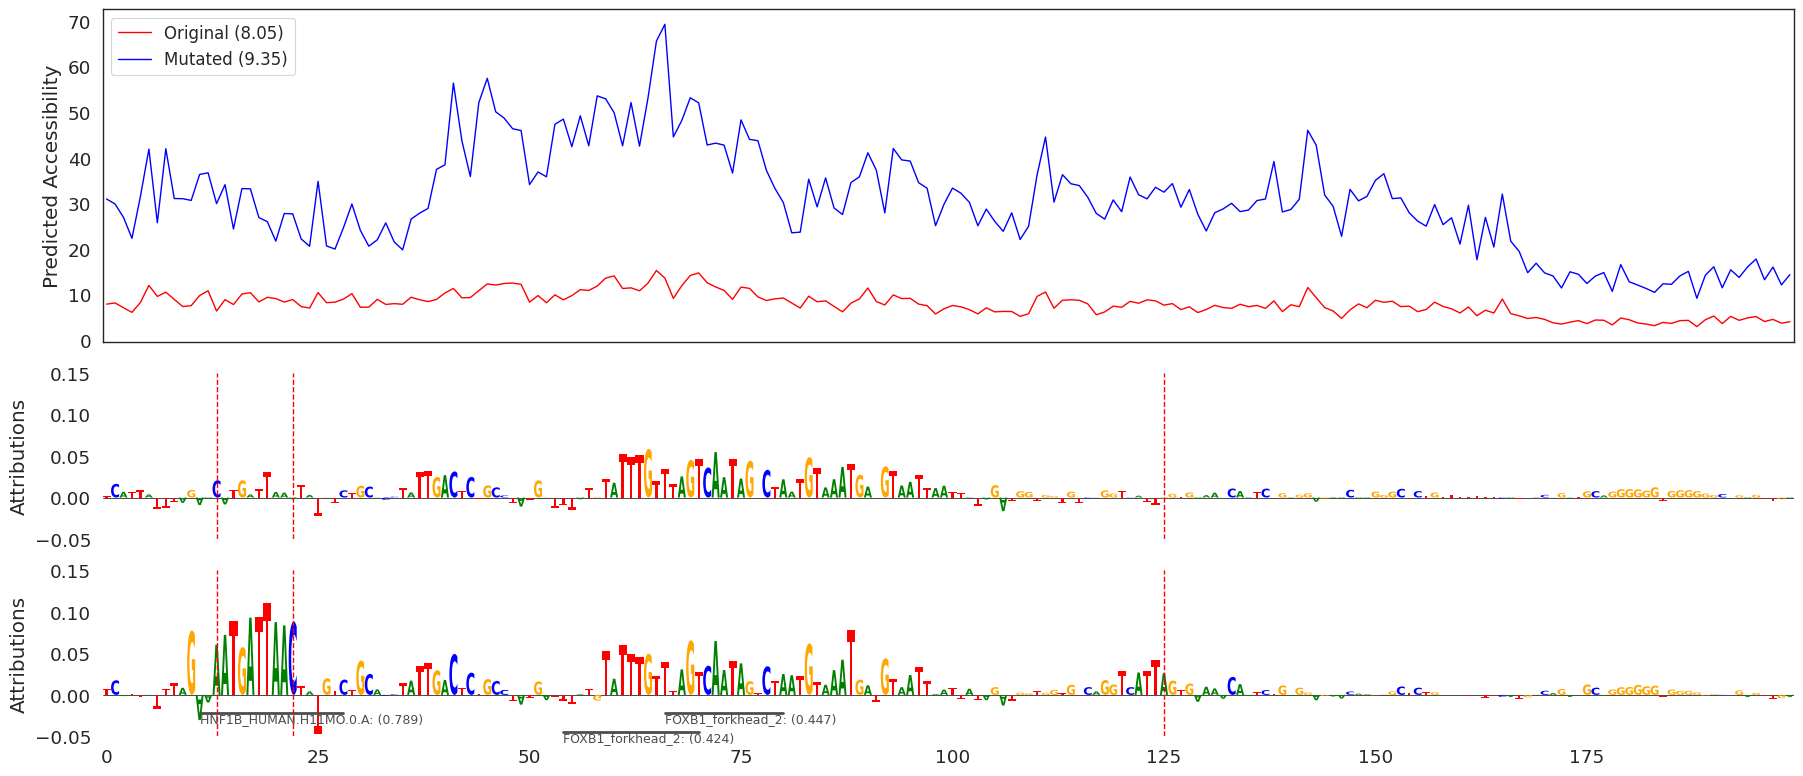

In [224]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [225]:
matched_preds = np.log(mutated_counts)

## Kinda maximize

In [313]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [314]:
X_ = torch.tensor(original_seq_onehot)

In [315]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=6,
    verbose=True,
)

Iteration 0/6 - y_hat: 8.048
Iteration 1/6 - y_hat: 8.541
Iteration 2/6 - y_hat: 8.866
Iteration 3/6 - y_hat: 9.351
Iteration 4/6 - y_hat: 9.717
Iteration 5/6 - y_hat: 10.105
Iteration 6/6 - y_hat: 10.493


In [316]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 26.90it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

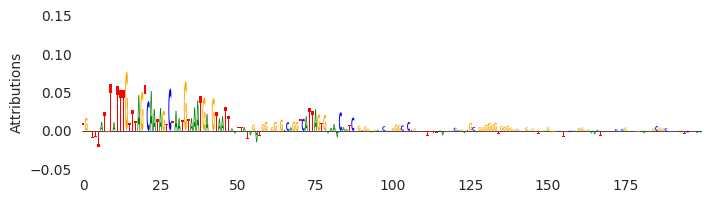

In [317]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [318]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(903, 'G', 'T'),
 (913, 'T', 'G'),
 (914, 'T', 'C'),
 (920, 'C', 'A'),
 (929, 'A', 'C'),
 (1032, 'G', 'A')]

In [319]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 36069.862163219776


((1000,), (1000,))

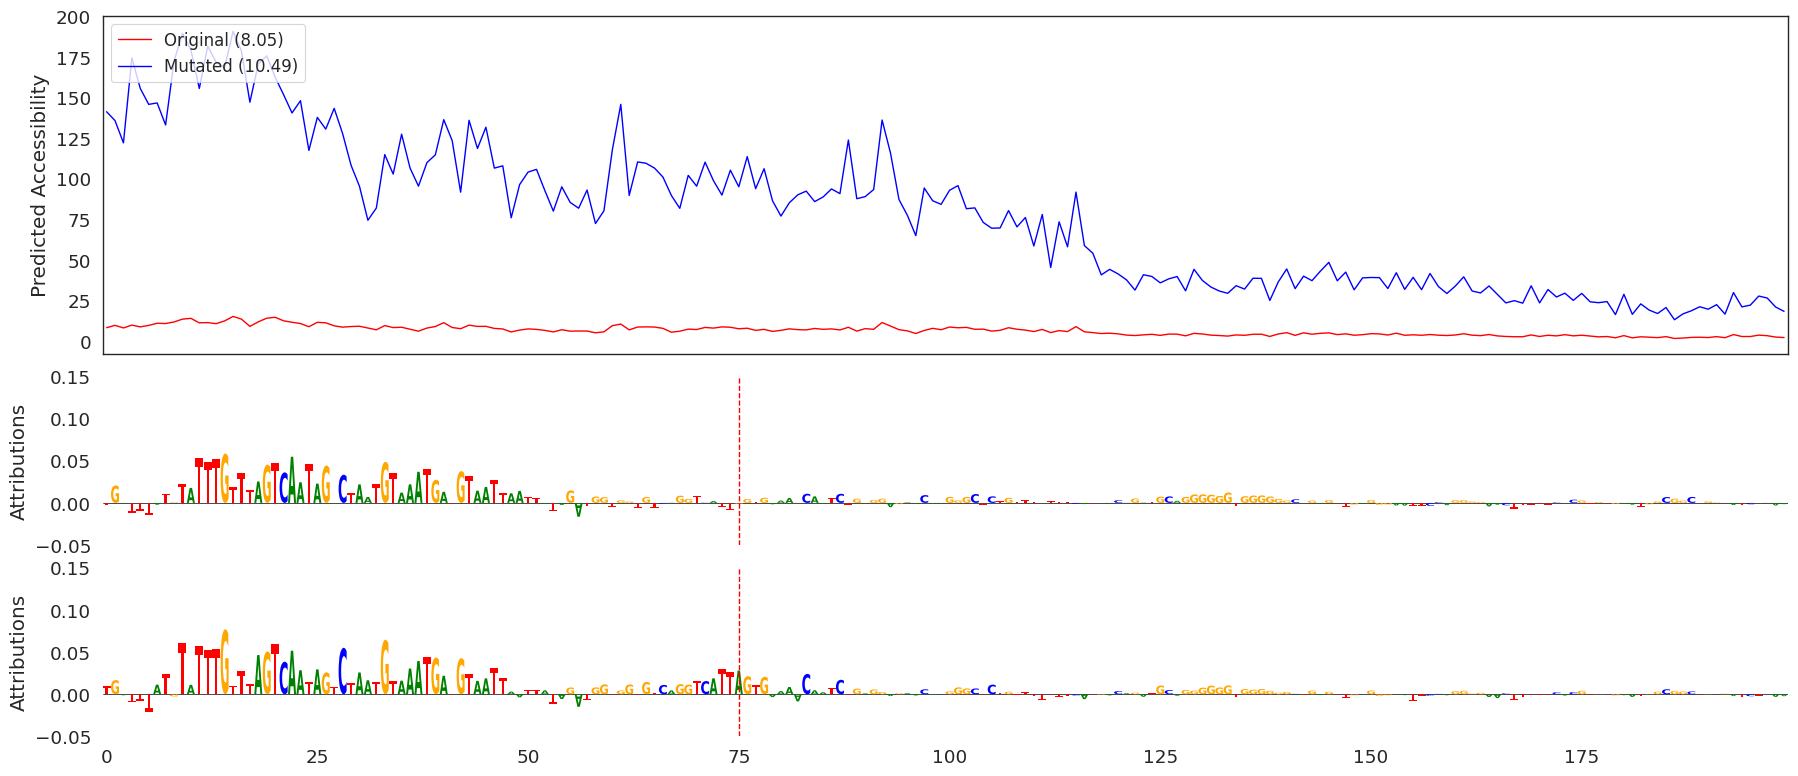

In [320]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [321]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [322]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,HNF1B_HUMAN.H11MO.0.A,902,919,1.095868,0.021858
1,HNF1B_HUMAN.H11MO.0.A,915,935,0.998441,0.033149


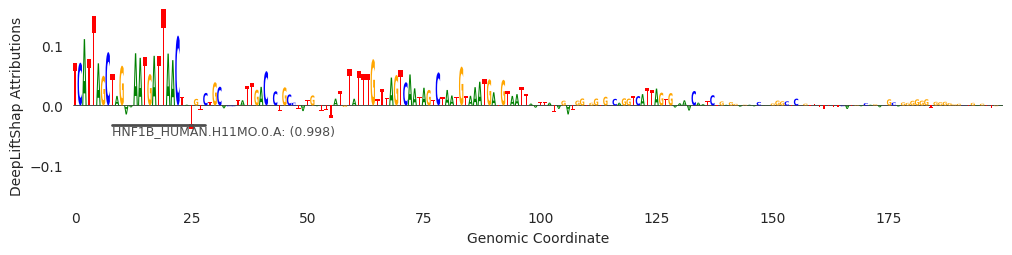

In [323]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

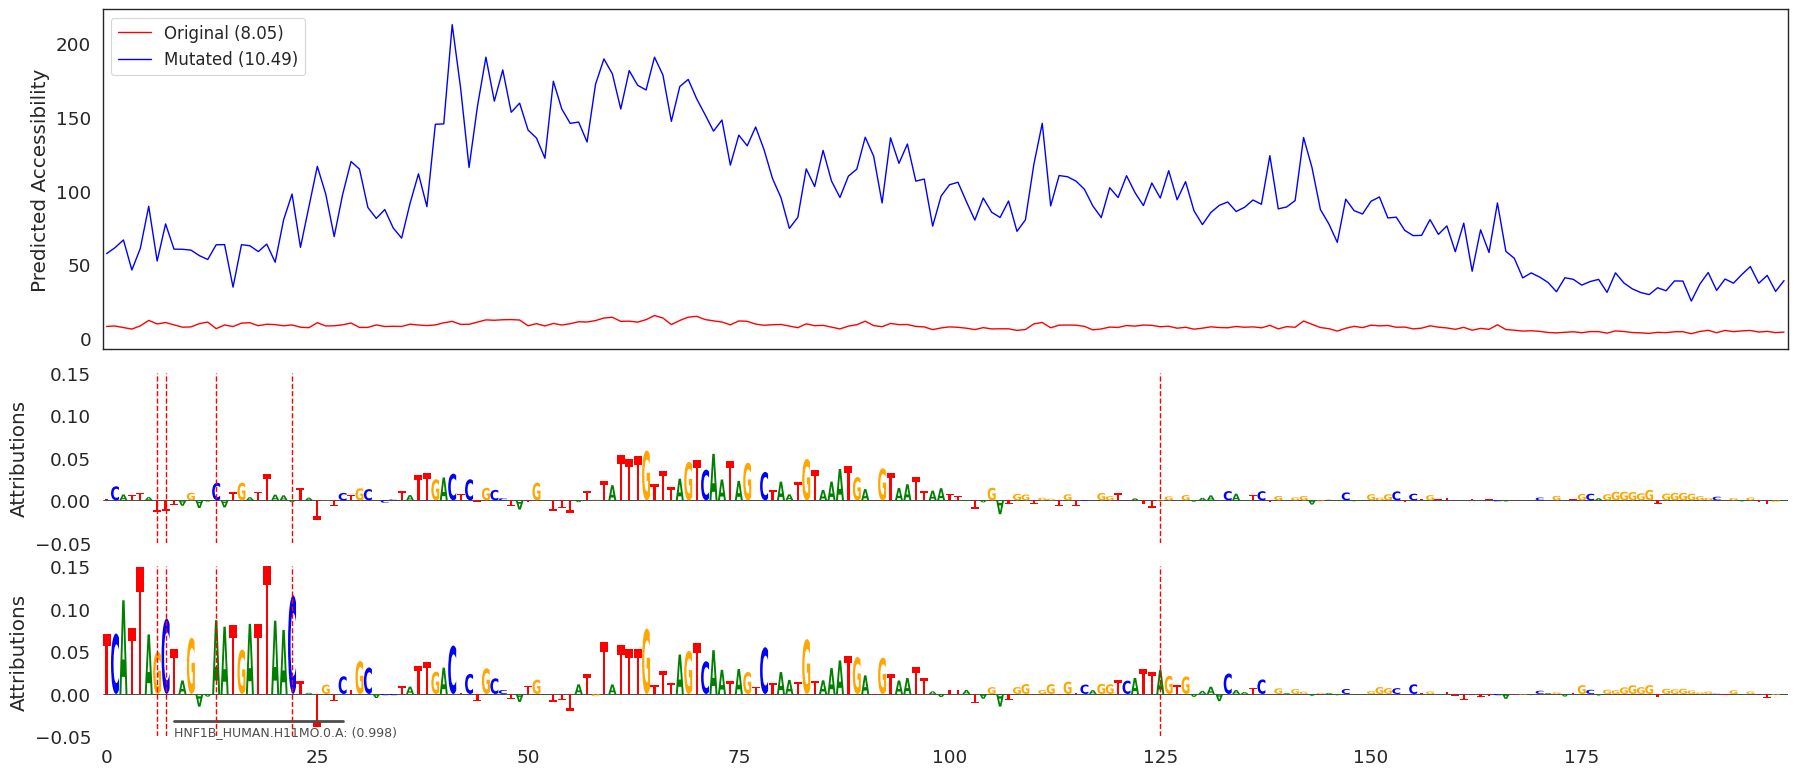

In [324]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [325]:
kinda_maximize_preds = np.log(mutated_counts)

## Minimize predictions

In [265]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [266]:
X_ = torch.tensor(original_seq_onehot)

In [267]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
    mode="minimize"
)

Iteration 0/10 - y_hat: 8.048
Iteration 1/10 - y_hat: 7.185
Iteration 2/10 - y_hat: 6.654
Iteration 3/10 - y_hat: 6.323
Iteration 4/10 - y_hat: 6.081
Iteration 5/10 - y_hat: 5.889
Iteration 6/10 - y_hat: 5.747
Iteration 7/10 - y_hat: 5.649
Iteration 8/10 - y_hat: 5.558
Iteration 9/10 - y_hat: 5.471
Iteration 10/10 - y_hat: 5.397


In [268]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 26.68it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

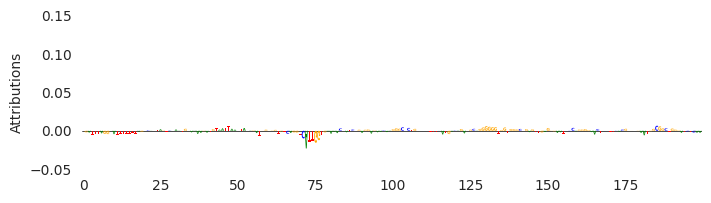

In [269]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [270]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(871, 'C', 'T'),
 (926, 'T', 'A'),
 (964, 'T', 'G'),
 (971, 'G', 'T'),
 (995, 'T', 'A'),
 (1094, 'G', 'T'),
 (1186, 'T', 'A'),
 (1189, 'G', 'T'),
 (1238, 'T', 'A'),
 (1288, 'C', 'T')]

In [271]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 220.90431983965686


((1000,), (1000,))

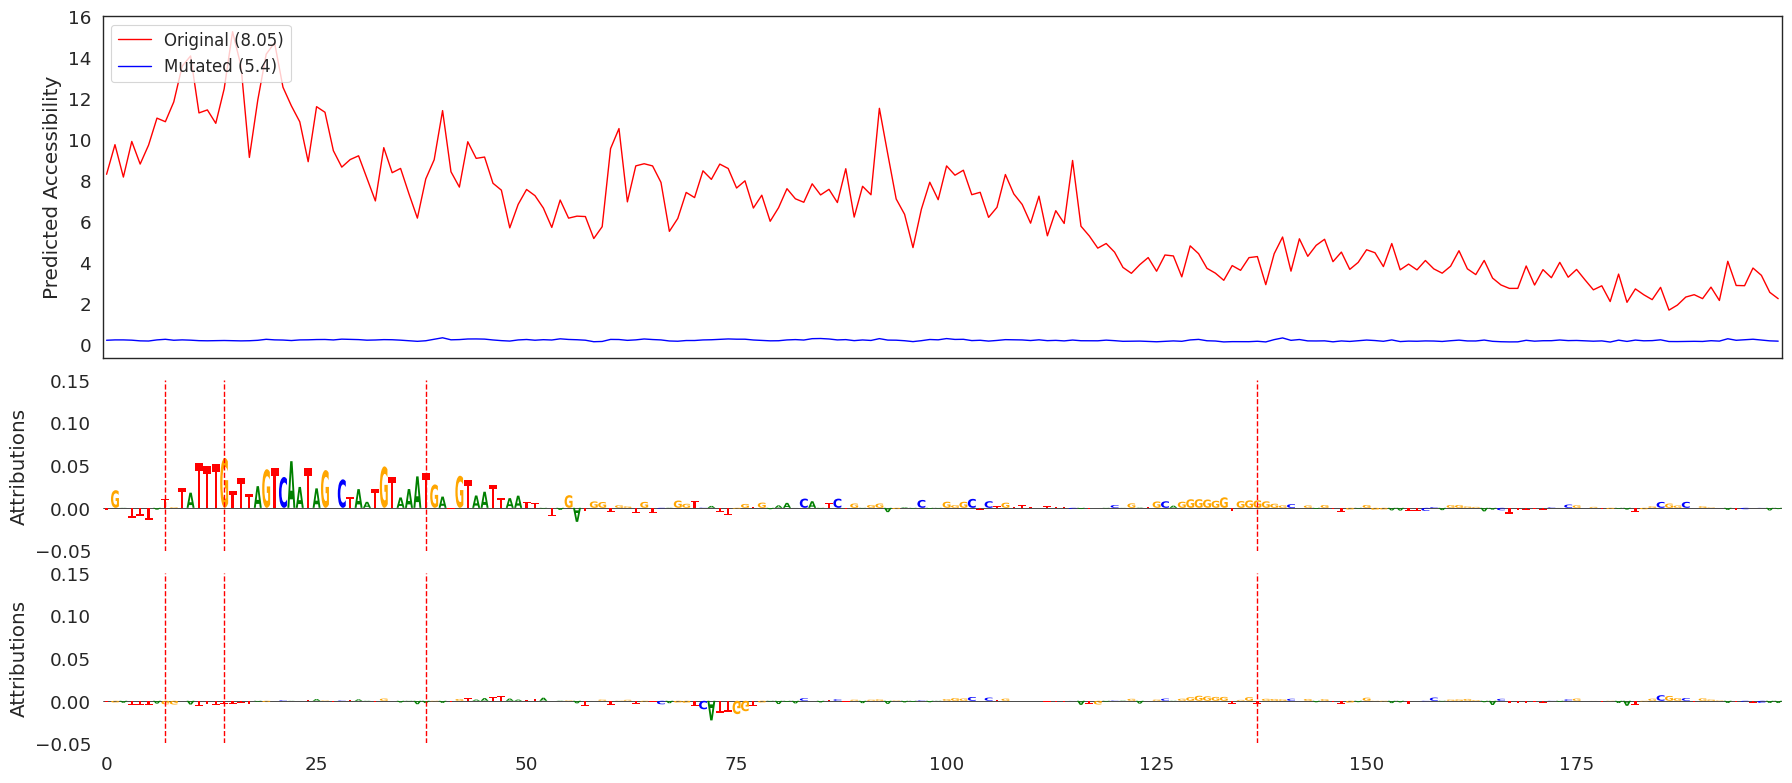

In [272]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [273]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [274]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOSL2_MOUSE.H11MO.0.A,1260,1274,0.034369,0.004237
1,NFYB_HUMAN.H11MO.0.A,1022,1040,-0.123666,0.011236
2,TYY1_HUMAN.H11MO.0.A,1179,1195,-0.078476,0.026820
3,TYY1_HUMAN.H11MO.0.A,1136,1150,0.010976,0.029661


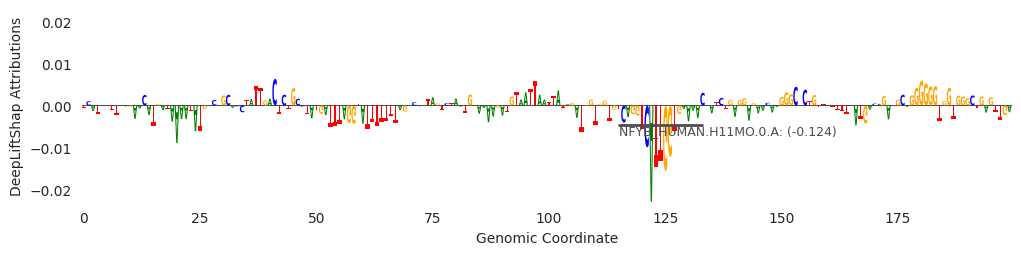

In [275]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

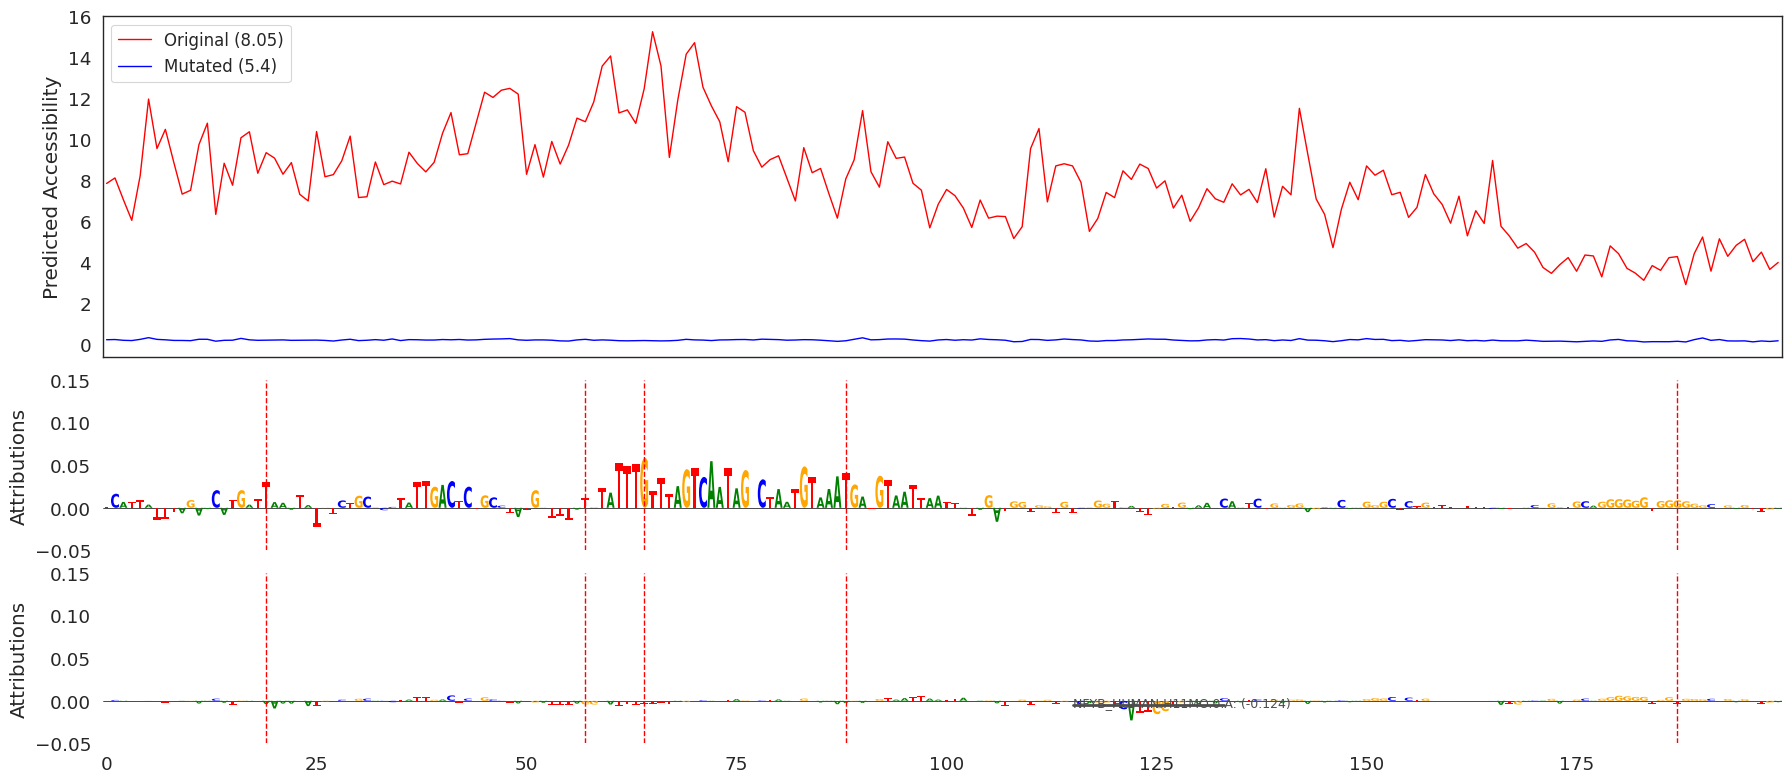

In [276]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [277]:
minimize_preds = np.log(mutated_counts)

## Somewhat minimize predictions

In [339]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [340]:
X_ = torch.tensor(original_seq_onehot)

In [341]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=3,
    verbose=True,
    mode="minimize"
)

Iteration 0/3 - y_hat: 8.048
Iteration 1/3 - y_hat: 7.185
Iteration 2/3 - y_hat: 6.654
Iteration 3/3 - y_hat: 6.323


In [342]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.07it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

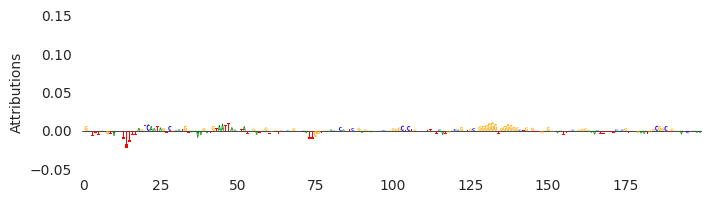

In [343]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [344]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(971, 'G', 'T'), (995, 'T', 'A'), (1238, 'T', 'A')]

In [345]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 557.1303534996094


((1000,), (1000,))

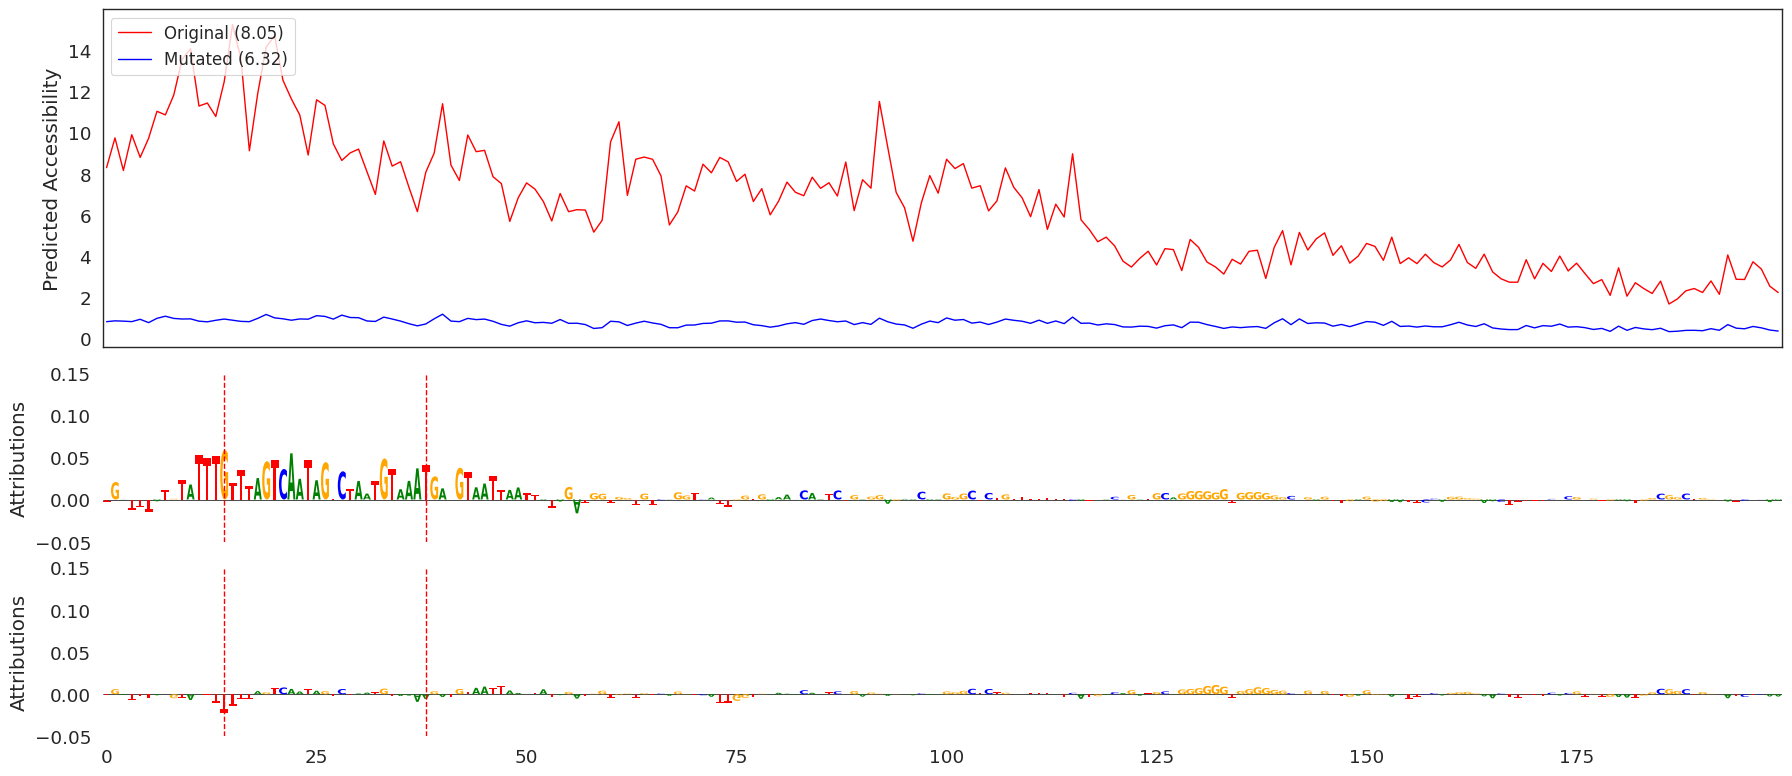

In [346]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [347]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [348]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,ZNF384_MA1125.1,965,979,-0.051582,3.774758e-15
1,FOSL2_MOUSE.H11MO.0.A,937,951,0.133015,3.225806e-03
2,NDF1_HUMAN.H11MO.0.A,1280,1296,0.114350,1.628664e-02
3,BHA15_HUMAN.H11MO.0.B,863,879,0.105661,2.258065e-02


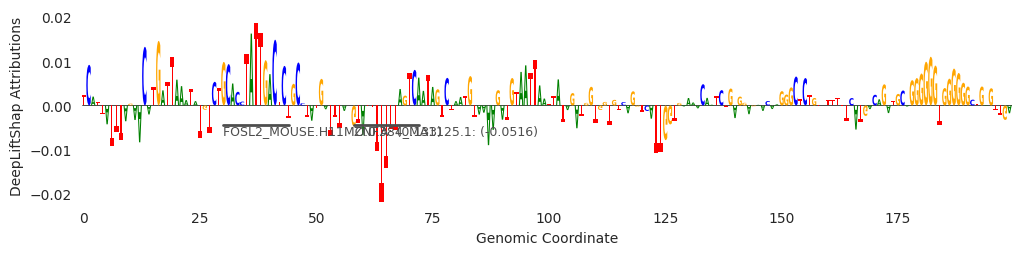

In [349]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

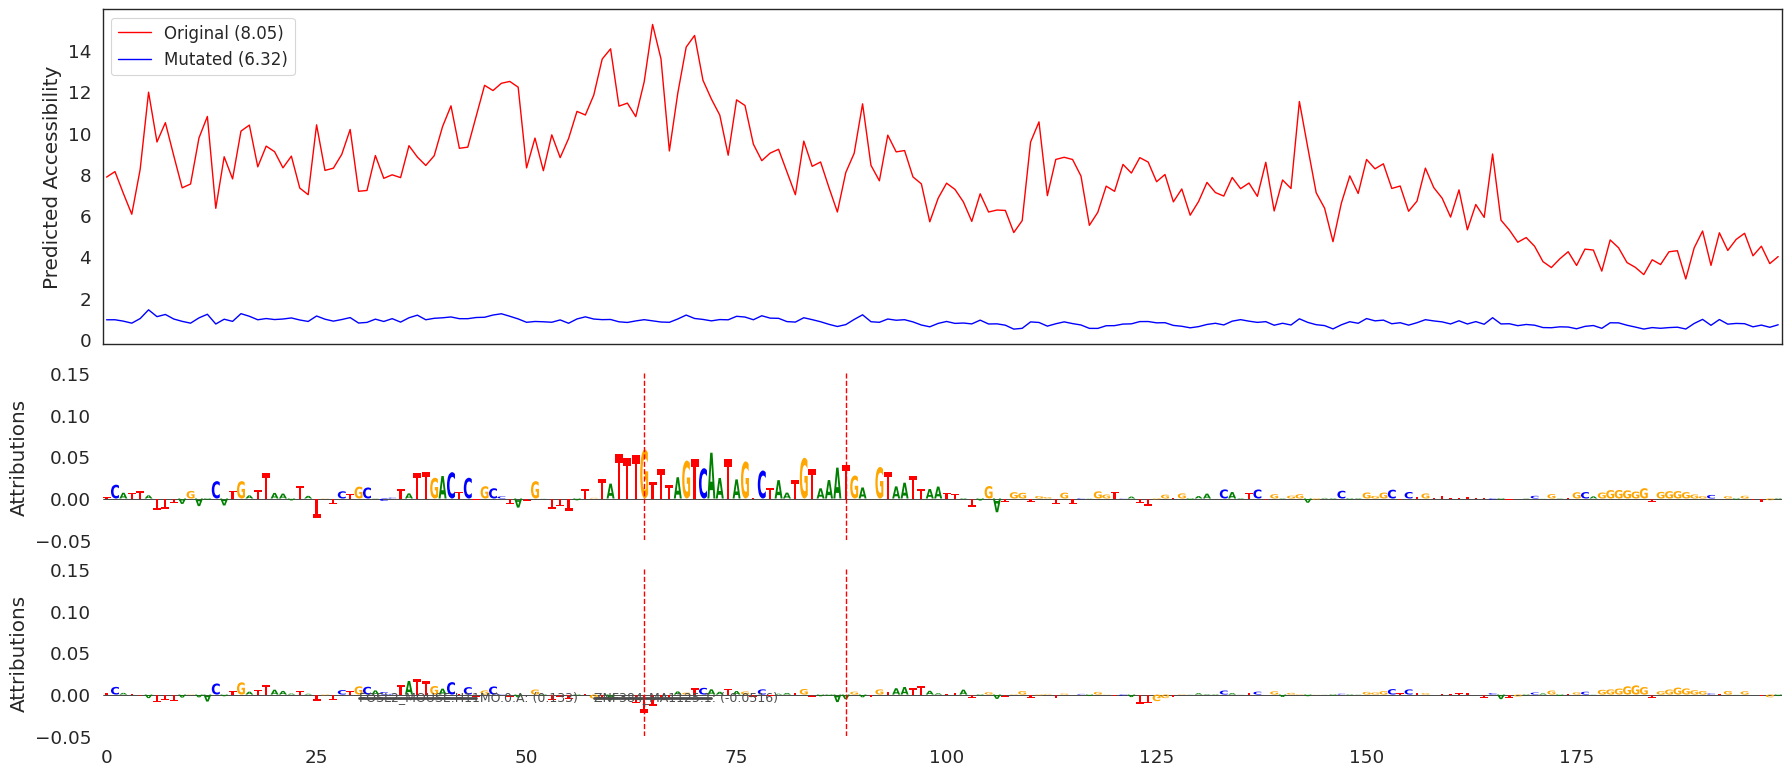

In [350]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [351]:
somewhat_minimize_preds = np.log(mutated_counts)

## kinda minimize predictions

In [369]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [370]:
X_ = torch.tensor(original_seq_onehot)

In [371]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=1,
    verbose=True,
    mode="minimize"
)

Iteration 0/1 - y_hat: 8.048
Iteration 1/1 - y_hat: 7.185


In [372]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.36it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

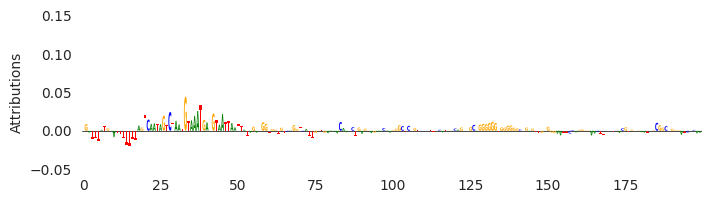

In [373]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [374]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(971, 'G', 'T')]

In [375]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 3128.3187360769625
mutated counts: 1320.2438686092526


((1000,), (1000,))

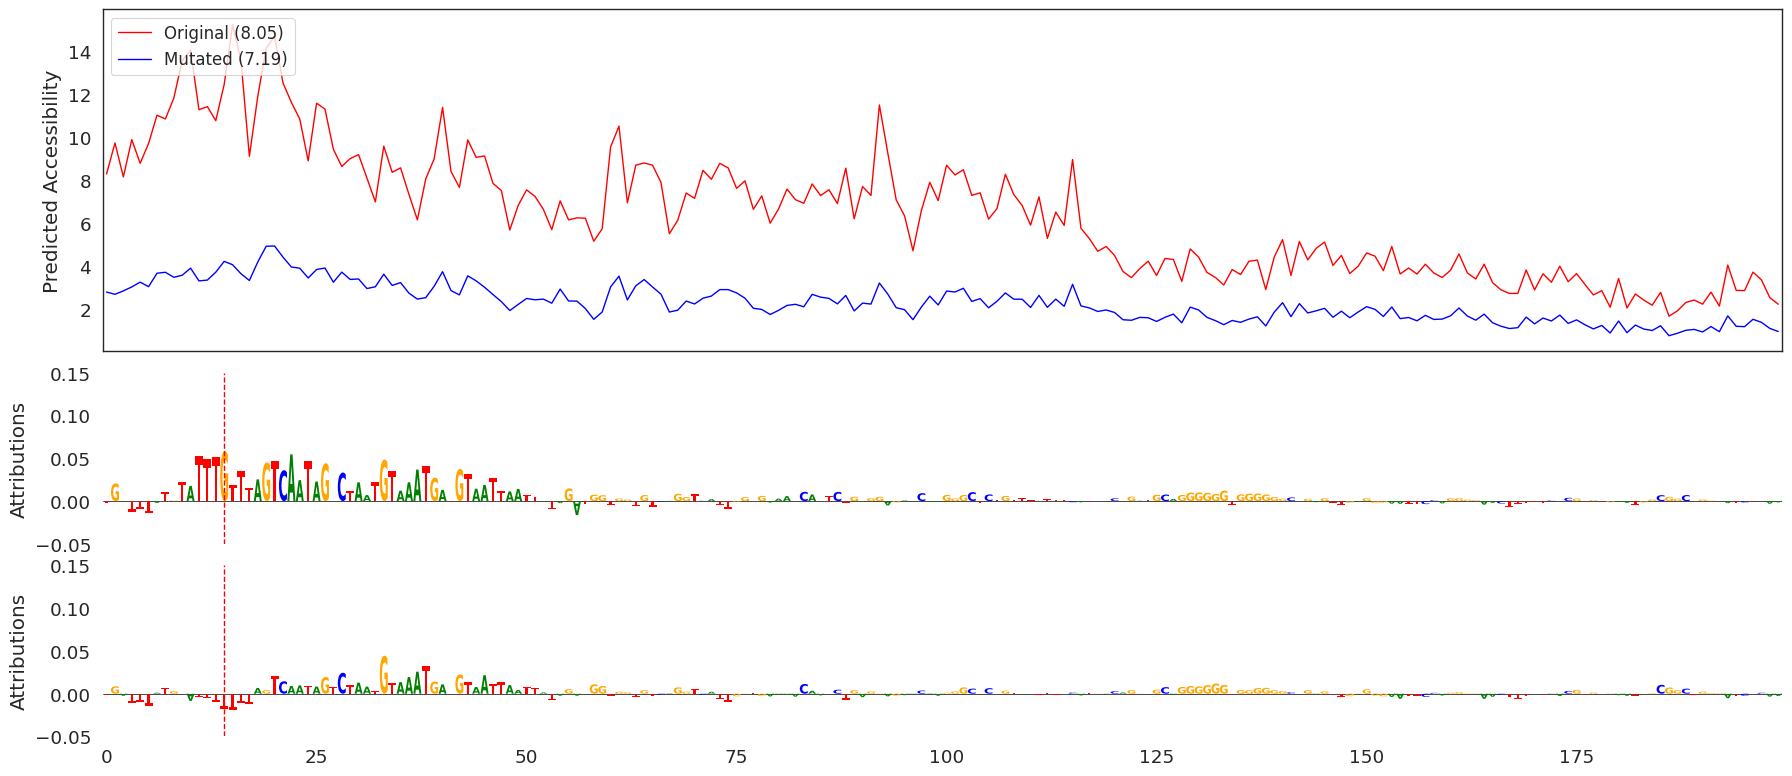

In [376]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [377]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [378]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,HNF1B_HUMAN.H11MO.0.A,985,1002,0.276102,0.006250
1,ZNF384_MA1125.1,963,980,-0.020368,0.017045
2,FOSL2_MOUSE.H11MO.0.A,940,954,0.156853,0.018462


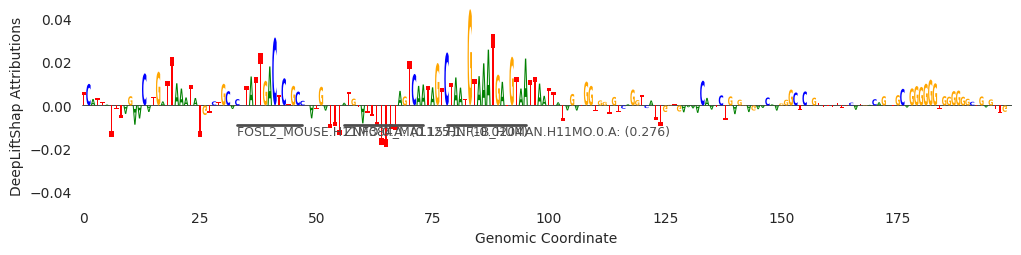

In [379]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start-50, end=plot_seq_end-50, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

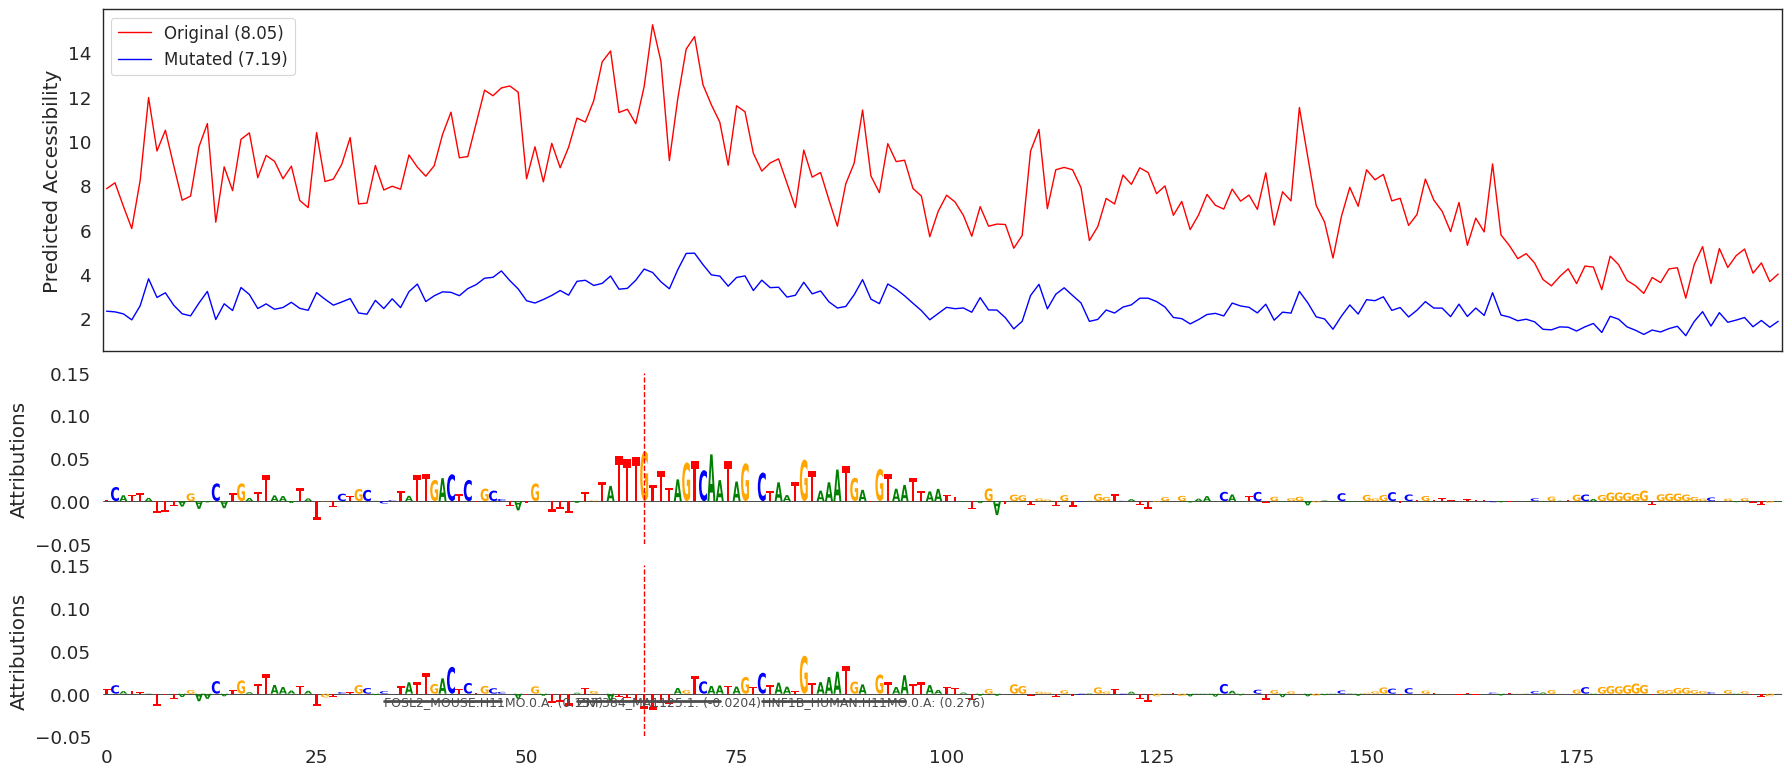

In [380]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [381]:
kinda_minimize_preds = np.log(mutated_counts)

# Distribution of single mutations

In [382]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [383]:
X_ = torch.tensor(original_seq_onehot)

In [384]:
from tangermeme.ism import saturation_mutagenesis

In [385]:
# Run ISM
y0, y_hat = saturation_mutagenesis(
    count_wrapper,
    X_,
    start=seq_start,
    end=seq_end,
    raw_outputs=True,
    verbose=True,
)

  0%|          | 0/63 [00:00<?, ?it/s]

100%|██████████| 63/63 [00:02<00:00, 30.61it/s]


In [386]:
# Optional mask
msk = (torch.abs(y_hat[:, :, :, 0] - y0[:, None, None, 0]) < 5e-4)
msk = msk.float()

In [387]:
attr = y_hat[:, :, :, 0] - y0[:, None, None, 0]
#attr = torch.exp(y_hat[:, :, :, 0]) - torch.exp(y0[:, None, None, 0])
attr = attr.numpy()

In [388]:
# Make all msk positions NaN
y_hat_np = y_hat[:, :, :, 0].cpu().numpy()
y_hat_np_msk = y_hat_np.copy()
y_hat_np_msk[msk.bool()] = np.nan

In [389]:
# Make a dataframe where x_axis is the position in the sequence and y-axis is forward_pred for y_hat_np[0] and reverse_pred for y_hat_np[1]
pred_df = pd.DataFrame(
    data=y_hat_np_msk.reshape(y_hat_np_msk.shape[0], -1).T, 
    columns=['preds']
)
pred_df.isna().sum(axis=0)

preds    512
dtype: int64

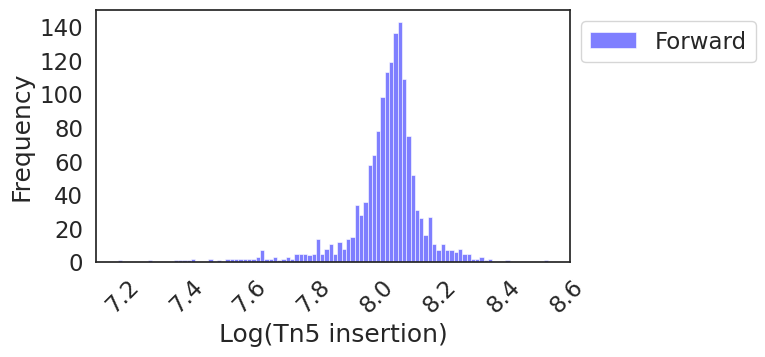

In [390]:
# Plot histograms of the forward predictions and the reverse predictions on same axis
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(data=pred_df, x='preds', color='blue', label='Forward', bins=100, ax=ax, alpha=0.5)

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()
    

# Plot all the mutations

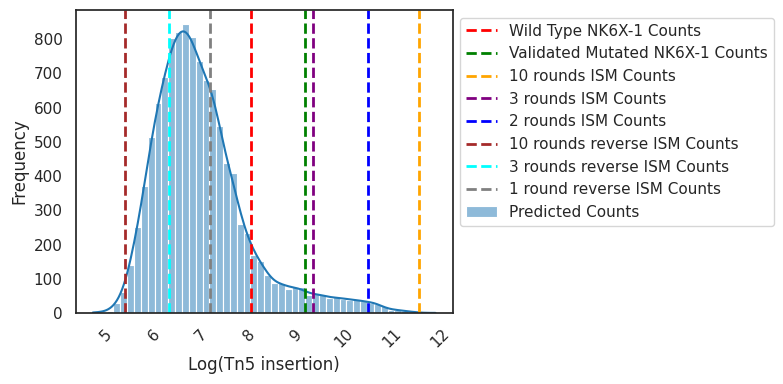

In [391]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        y_0,
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot NKX6-1 Enhancer Original as vertical line
    ax.axvline(x=wild_type_enhancer_counts, color='red', linestyle='--', linewidth=2, label='Wild Type NK6X-1 Counts')
    
    # Plot NKX6-1 Enhancer Mutated as vertical line
    ax.axvline(x=validated_mutated_enhancer_counts, color='green', linestyle='--', linewidth=2, label='Validated Mutated NK6X-1 Counts')

    # Plot the maximum counts as vertical line
    ax.axvline(x=maximum_counts, color='orange', linestyle='--', linewidth=2, label='10 rounds ISM Counts')

    # Plot the matched counts as vertical line
    ax.axvline(x=matched_preds, color='purple', linestyle='--', linewidth=2, label='3 rounds ISM Counts')

    # Plot the kinda maximized counts as vertical line
    ax.axvline(x=kinda_maximize_preds, color='blue', linestyle='--', linewidth=2, label='2 rounds ISM Counts')

    # Plot the minimized counts as vertical line
    ax.axvline(x=minimize_preds, color='brown', linestyle='--', linewidth=2, label='10 rounds reverse ISM Counts')
    
    # Plot the somewhat minimized counts as vertical line
    ax.axvline(x=somewhat_minimize_preds, color='cyan', linestyle='--', linewidth=2, label='3 rounds reverse ISM Counts')

    # Plot the kinda minimized counts as vertical line
    ax.axvline(x=kinda_minimize_preds, color='gray', linestyle='--', linewidth=2, label='1 round reverse ISM Counts')
    
    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# DONE!

---